# Projeto de Previsão de Demandas de Bicicletas Compartilhadas

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.3 MB/s eta 0:00:00


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import optuna

import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving hour.csv to hour.csv
User uploaded file "hour.csv" with length 1156736 bytes


### Carregamento do Dataset

In [ ]:
df = pd.read_csv("hour.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


##EDA

### 1. Visão geral do conjunto de dados

Este conjunto de dados contém informações horárias sobre o sistema de compartilhamento de bicicletas nos anos de 2011 e 2012. O principal objetivo é prever a demanda total por bicicletas (`cnt`) com base em características ambientais e sazonais. Este é um problema de regressão.

In [ ]:
num_linhas, num_colunas = df.shape
print(f"Número de linhas: {num_linhas}")
print(f"Número de colunas: {num_colunas}")
print(f"Dimensão do conjunto de dados: {num_linhas} linhas x {num_colunas} colunas")

Número de linhas: 17379
Número de colunas: 17
Dimensão do conjunto de dados: 17379 linhas x 17 colunas


### 2. Inspeção inicial

O dataset possui **17379 registros** e **17 atributos**. Não há valores nulos, indicando que o dataset está completo em termos de preenchimento de dados.

#### Tipos de variáveis

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


**Observações sobre os tipos de variáveis:**
*   **Numéricas (int64/float64):** `instant`, `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, `casual`, `registered`, `cnt`.
*   **Temporal (object):** `dteday` está como `object` e precisará ser convertida para o tipo `datetime` para análises temporais.
*   **Categóricas/Binárias:** Muitas das variáveis `int64` como `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit` são, na verdade, variáveis categóricas ou binárias que representam categorias ou estados, e não grandezas contínuas.
*   **Variável Alvo:** `cnt` (contagem total de aluguéis) é a variável numérica que será predita.

#### Primeiras linhas da base (`head()`)

In [ ]:
display(df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Observações sobre as primeiras linhas:**
*   O DataFrame mostra as primeiras 5 horas do dia 01/01/2011.
*   `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit` são representadas por códigos numéricos, confirmando sua natureza categórica/binária.
*   `temp`, `atemp`, `hum`, `windspeed` são valores normalizados (entre 0 e 1).
*   `casual`, `registered`, `cnt` mostram a contagem de usuários por tipo e o total de aluguéis, respectivamente. Percebe-se que `cnt` é a soma de `casual` e `registered`.

#### Estatísticas descritivas (`describe()`)

In [ ]:
display(df.describe(include='float64'))

,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098
std,0.192556,0.171850,0.192930,0.122340
min,0.020000,0.000000,0.000000,0.000000
25%,0.340000,0.333300,0.480000,0.104500
50%,0.500000,0.484800,0.630000,0.194000
75%,0.660000,0.621200,0.780000,0.253700
max,1.000000,1.000000,1.000000,0.850700


**Observações sobre as estatísticas descritivas:**
*   **`instant`:** É um identificador sequencial, não deve ser usado diretamente como feature.
*   **Variáveis categóricas (`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`):** As estatísticas aqui mostram a distribuição dos códigos, mas é mais informativo convertê-los para categorias ou dummy variables.
*   **Variáveis climáticas (`temp`, `atemp`, `hum`, `windspeed`):** Estão normalizadas, com médias e desvios padrão que indicam a variação dentro do intervalo [0, 1]. `windspeed` possui um mínimo de 0, o que pode indicar dias sem vento ou erro na medição (embora o significado normalizado seja 0 para o mínimo).
*   **Variáveis de demanda (`casual`, `registered`, `cnt`):**
    *   `cnt` varia de 1 a 977, com média de ~189 aluguéis por hora. O desvio padrão é alto (~181), indicando grande variabilidade na demanda.
    *   O valor máximo de `cnt` é 977, enquanto `casual` é 367 e `registered` é 886. A demanda de usuários registrados é significativamente maior que a de usuários casuais.
    *   Os mínimos de `casual`, `registered` e `cnt` são 0 ou 1, o que é esperado.

### 3. Documentação das variáveis

| Coluna | Significado | Tipo | Possível influência na demanda |
|---|---|---|---|
| instant | Índice de registro | Numérica | Identificador único; não deve influenciar a demanda diretamente, mas útil para ordenação ou junções. |
| dteday | Data da ocorrência | Temporal | Variações sazonais, tendências anuais, e eventos específicos ao longo do tempo. |
| season | Estação do ano (1:primavera, 2:verão, 3:outono, 4:inverno) | Categórica | A demanda tende a ser maior em estações mais quentes (verão/outono) e menor no inverno. |
| yr | Ano (0:2011, 1:2012) | Binária | Tendência anual na demanda; pode indicar crescimento ou decréscimo ao longo dos anos. |
| mnth | Mês (1 a 12) | Categórica | Variações mensais na demanda (e.g., meses de férias, feriados específicos do mês). |
| hr | Hora do dia (0 a 23) | Categórica | Picos de demanda em horários de pico (manhã e fim de tarde) e redução em horários de menor movimento. |
| holiday | Se o dia é feriado (1) ou não (0) | Binária | A demanda pode variar significativamente em feriados (geralmente menor em feriados de trabalho, mas maior em feriados recreativos). |
| weekday | Dia da semana (0:Domingo, ..., 6:Sábado) | Categórica | Padrões de demanda diferentes em dias úteis (maior demanda de registrados) e fins de semana (maior demanda de casuais). |
| workingday | Se o dia é útil (1) ou não (0) | Binária | Similar ao `weekday`, mas focado na distinção entre dias de trabalho e não trabalho. |
| weathersit | Situação climática (1:limpo, 2:neblina/nublado, 3:chuva/neve leve, 4:chuva forte/neve) | Categórica | Condições climáticas adversas (chuva, neve) geralmente reduzem a demanda, enquanto tempo bom a aumenta. |
| temp | Temperatura normalizada em Celsius | Numérica | Temperaturas agradáveis tendem a aumentar a demanda; temperaturas extremas (muito frio ou muito quente) podem diminuir. |
| atemp | Sensação térmica normalizada em Celsius | Numérica | Similar à temperatura, mas reflete a sensação, que pode ser um preditor mais preciso do conforto para andar de bicicleta. |
| hum | Umidade normalizada | Numérica | Umidade muito alta pode ser desconfortável e reduzir a demanda. |
| windspeed | Velocidade do vento normalizada | Numérica | Ventos fortes podem dificultar o uso da bicicleta e reduzir a demanda. |
| casual | Contagem de usuários casuais | Numérica | Componente da demanda total; útil para entender diferentes perfis de usuários e pode ser influenciado mais por fatores climáticos e recreativos. |
| registered | Contagem de usuários registrados | Numérica | Componente da demanda total; útil para entender diferentes perfis de usuários e pode ser influenciado mais por fatores de rotina (trabalho/estudo). |
| cnt | Contagem total de bicicletas alugadas (casual + registrado) | Variável Alvo (Numérica) | É a variável que se busca prever; representa a demanda geral pelo serviço de compartilhamento de bicicletas. |

## Hipóteses

### Hipótese 1: Horários de pico influenciam fortemente a demanda.

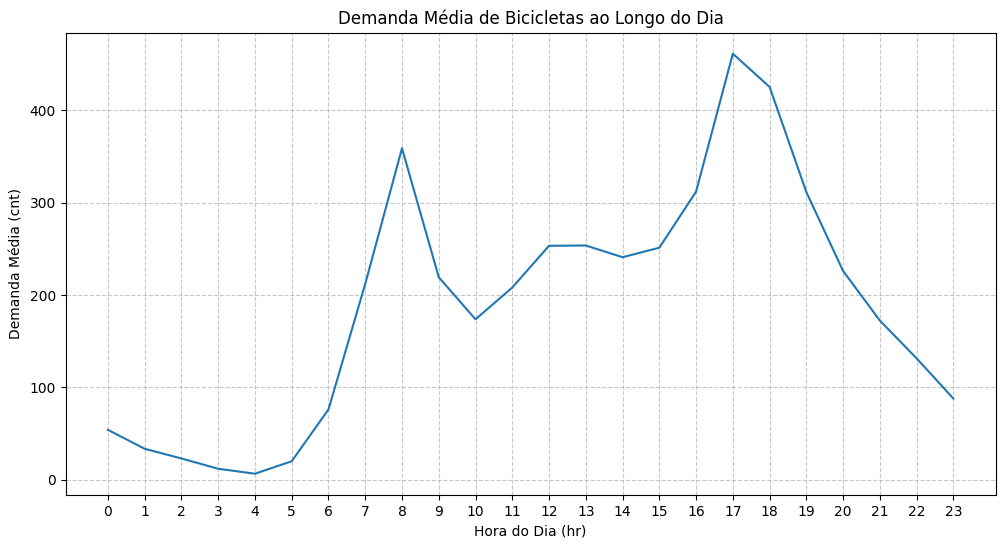

In [ ]:
demanda_por_hora = df.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=demanda_por_hora)
plt.title('Demanda Média de Bicicletas ao Longo do Dia')
plt.xlabel('Hora do Dia (hr)')
plt.ylabel('Demanda Média (cnt)')
plt.xticks(range(0, 24)) # Garante que todas as horas sejam exibidas no eixo X
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Interpretação dos Resultados:

O gráfico de linha da demanda média de bicicletas por hora revela padrões claros de utilização ao longo do dia, que se alinham à rotina diária da maioria das pessoas:

*   **Horários de Menor Demanda:** A demanda é significativamente baixa durante as horas da madrugada, aproximadamente entre 00:00 (meia-noite) e 05:00. Isso é esperado, pois a maioria das atividades cessa nesse período.

*   **Horários de Pico:** Existem dois picos distintos de utilização:
    *   **Pico da Manhã:** Ocorre por volta das **08:00**, indicando um aumento acentuado na demanda, provavelmente relacionado ao deslocamento das pessoas para o trabalho ou estudo.
    *   **Pico da Tarde/Noite:** Ocorre entre **17:00 e 18:00**, apresentando o maior volume de demanda. Este pico é ainda mais proeminente que o da manhã, sugerindo que o retorno das atividades diárias é um momento de alta utilização de bicicletas compartilhadas.

*   **Comportamento Intermediário:** Durante o período da manhã, após o pico das 08:00, a demanda se mantém em um nível intermediário, com uma leve queda no período do almoço (entre 12:00 e 14:00), e volta a crescer gradualmente até atingir o pico da tarde.

*   **Declínio Pós-Pico:** Após o pico da tarde/noite, a demanda começa a declinar progressivamente, voltando aos níveis baixos da madrugada.

Esses padrões observados no gráfico sugerem uma forte correlação com a rotina diária das pessoas, com a demanda sendo impulsionada pelos horários de deslocamento (ida e volta do trabalho/estudo) e reduzida nos períodos de descanso.

### Hipótese 2 : A demanda por bicicletas apresenta comportamento diferente entre dias úteis e dias não úteis.


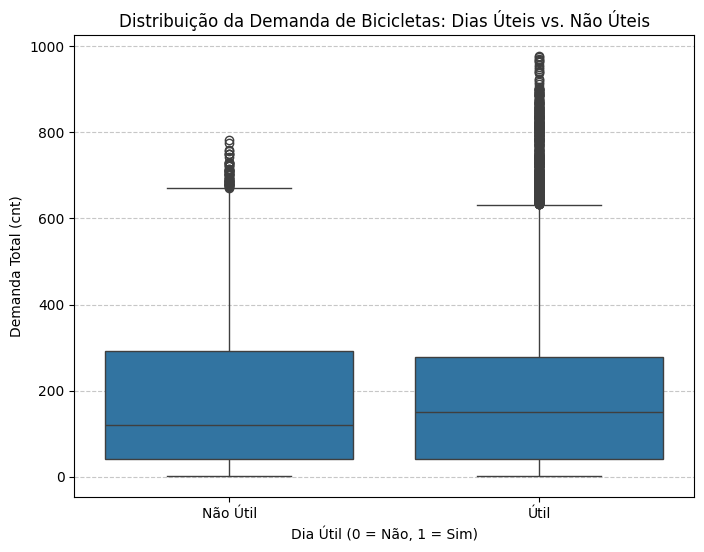

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='workingday', y='cnt', data=df)
plt.title('Distribuição da Demanda de Bicicletas: Dias Úteis vs. Não Úteis')
plt.xlabel('Dia Útil (0 = Não, 1 = Sim)')
plt.ylabel('Demanda Total (cnt)')
plt.xticks([0, 1], ['Não Útil', 'Útil'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretação dos Resultados:

O boxplot compara a distribuição da demanda total de bicicletas (`cnt`) entre dias não úteis (`workingday` = 0) e dias úteis (`workingday` = 1):

*   **Diferenças entre as Medianas:**
    *   A mediana da demanda em **dias úteis** (caixa à direita) é visivelmente maior do que a mediana em **dias não úteis** (caixa à esquerda). Isso sugere que, em média, a demanda por bicicletas é maior durante os dias de semana.

*   **Diferenças na Dispersão dos Valores:**
    *   A caixa do boxplot para **dias úteis** é mais alongada e deslocada para cima, indicando uma maior variabilidade na demanda e valores geralmente mais altos. A dispersão dos dados em dias úteis é maior, cobrindo um espectro mais amplo de contagens.
    *   A caixa do boxplot para **dias não úteis** é mais compacta e localizada em valores de demanda mais baixos, indicando menor variabilidade e contagens mais consistentemente baixas.

*   **Presença de Outliers:**
    *   Ambos os grupos apresentam outliers (pontos individuais além dos "bigodes"), indicando que há horários específicos em dias úteis e não úteis com demanda excepcionalmente alta ou baixa, que fogem do padrão geral. Em dias úteis, há outliers de demanda muito alta, enquanto em dias não úteis, os outliers de demanda alta são menos frequentes e de menor magnitude.

*   **Diferença Perceptível entre os Grupos:**
    *   Sim, há uma diferença clara e perceptível na distribuição da demanda entre os dois grupos. A demanda em dias úteis tende a ser não apenas maior em média, mas também mais variável e com picos de utilização mais elevados.

*   **Evidências para a Hipótese:**
    *   Os resultados observados **sustentam fortemente a hipótese** de que a demanda por bicicletas apresenta comportamento diferente entre dias úteis e dias não úteis. A maior mediana e dispersão, juntamente com os picos mais altos em dias úteis, sugerem que os padrões de uso (como deslocamentos para trabalho/estudo) influenciam a demanda de forma distinta em comparação com os dias de lazer ou feriados.

### Hipótese 3: Clima severo reduz a utilização das bicicletas.

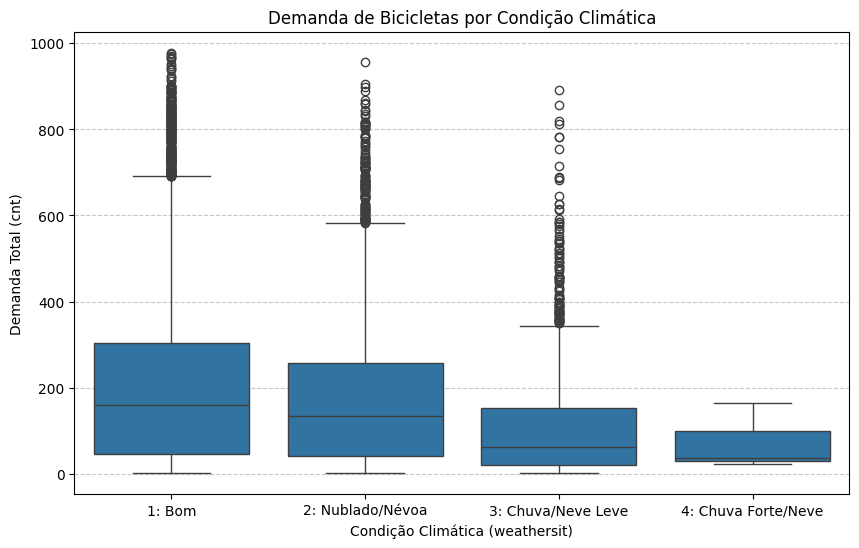

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title('Demanda de Bicicletas por Condição Climática')
plt.xlabel('Condição Climática (weathersit)')
plt.ylabel('Demanda Total (cnt)')
plt.xticks([0, 1, 2, 3], ['1: Bom', '2: Nublado/Névoa', '3: Chuva/Neve Leve', '4: Chuva Forte/Neve'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretação dos Resultados:

O boxplot exibe a distribuição da demanda total de bicicletas (`cnt`) para cada uma das quatro condições climáticas (`weathersit`):

*   **Comparação das Medianas:**
    *   A mediana da demanda é visivelmente maior na condição climática **1 (Bom)**.
    *   As medianas decrescem progressivamente nas condições **2 (Nublado/Névoa)** e **3 (Chuva/Neve Leve)**.
    *   Na condição **4 (Chuva Forte/Neve)**, a mediana é a mais baixa de todas, indicando uma demanda mínima.

*   **Comparação da Dispersão dos Valores:**
    *   As caixas (intervalo interquartil) são mais amplas para as condições **1 e 2**, indicando maior variabilidade e uma gama maior de demandas nessas condições.
    *   A dispersão diminui consideravelmente nas condições **3 e 4**, onde as caixas são mais estreitas e os valores de demanda estão mais concentrados em níveis baixos.

*   **Identificação de Possíveis Outliers:**
    *   As condições **1 e 2** apresentam diversos outliers de alta demanda, sugerindo que mesmo em dias de tempo bom ou levemente nublado, pode haver picos de utilização muito altos.
    *   A condição **3** também possui alguns outliers, mas em menor quantidade e com valores máximos menores que nas condições 1 e 2.
    *   A condição **4** não mostra outliers de alta demanda, e os poucos pontos individuais são relativamente baixos, reforçando a extrema baixa utilização.

*   **Verificação de Indícios que Sustentem ou Refutem a Hipótese:**
    *   Os padrões observados no gráfico **sustentam fortemente a hipótese** de que condições climáticas mais severas reduzem a utilização das bicicletas compartilhadas. À medida que a condição climática piora (do 1 para o 4), há uma clara tendência de queda na mediana da demanda, menor dispersão dos dados e uma ausência de picos de alta utilização. Isso sugere que os usuários evitam as bicicletas em tempo adverso.

### Hipótese 4 : Existe sazonalidade mensal na demanda por bicicletas compartilhadas.


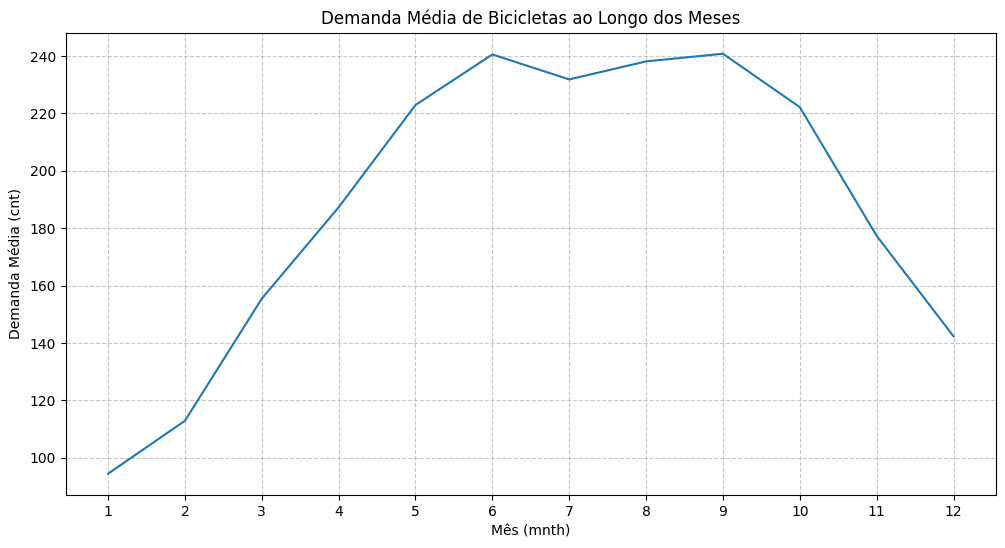

In [ ]:
demanda_por_mes = df.groupby('mnth')['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='mnth', y='cnt', data=demanda_por_mes)
plt.title('Demanda Média de Bicicletas ao Longo dos Meses')
plt.xlabel('Mês (mnth)')
plt.ylabel('Demanda Média (cnt)')
plt.xticks(range(1, 13)) # Garante que todos os meses sejam exibidos no eixo X
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Interpretação dos Resultados:

O gráfico de linha da demanda média de bicicletas ao longo dos meses revela uma clara sazonalidade na utilização do serviço:

*   **Meses com Maior Demanda:** A demanda começa a crescer a partir de março, atinge seu pico máximo nos meses de **junho, julho, agosto, setembro e outubro**, mantendo-se em patamares elevados.

*   **Meses com Menor Demanda:** A demanda é notavelmente menor nos meses de **janeiro e fevereiro**, iniciando um declínio acentuado a partir de novembro, com dezembro também apresentando demanda reduzida.

*   **Tendências de Crescimento e Redução:**
    *   Observa-se uma tendência de **crescimento constante** na demanda do início do ano (janeiro) até meados do ano (junho/julho).
    *   Após atingir o pico, a demanda se mantém estável em um patamar alto até outubro, quando inicia uma tendência de **redução significativa** em novembro e dezembro.

*   **Evidências de Sazonalidade:** O padrão de demanda crescente na primavera, alta no verão/outono e baixa no inverno é uma forte evidência de sazonalidade mensal, o que é esperado para um serviço de bicicletas compartilhadas, que é altamente influenciado por condições climáticas e atividades ao ar livre.

*   **Sustentação da Hipótese:** Os resultados observados no gráfico **sustentam fortemente a hipótese** de que existe sazonalidade mensal na demanda por bicicletas compartilhadas. A variação consistente nos níveis de demanda média ao longo do ano, com picos nos meses mais quentes e quedas nos meses mais frios, indica que fatores mensais (como clima, férias escolares e feriados) influenciam diretamente a utilização do serviço.

### Hipótese 5: A demanda por bicicletas compartilhadas varia entre as estações do ano.

/tmp/ipykernel_570/2116461857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=demanda_por_estacao, palette='viridis')


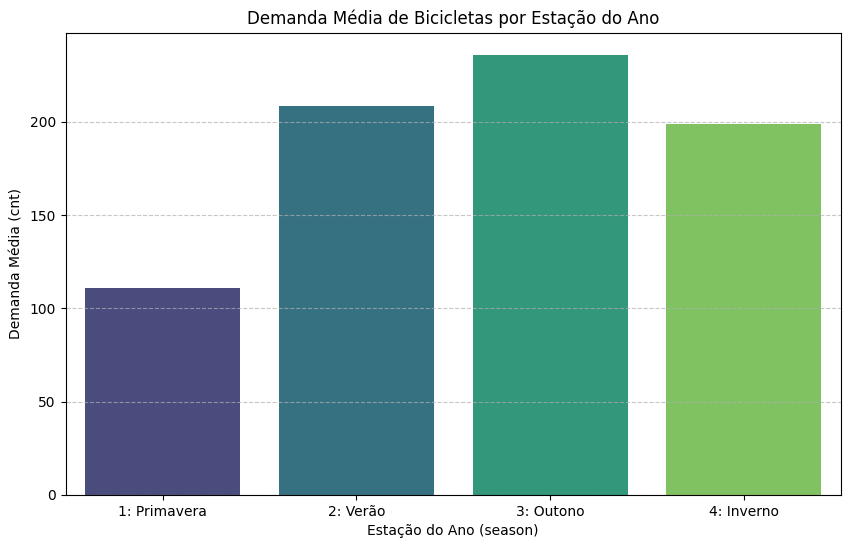

In [ ]:
demanda_por_estacao = df.groupby('season')['cnt'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='season', y='cnt', data=demanda_por_estacao, palette='viridis')
plt.title('Demanda Média de Bicicletas por Estação do Ano')
plt.xlabel('Estação do Ano (season)')
plt.ylabel('Demanda Média (cnt)')
plt.xticks([0, 1, 2, 3], ['1: Primavera', '2: Verão', '3: Outono', '4: Inverno'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretação dos Resultados:

O gráfico de barras mostra a demanda média de bicicletas compartilhadas para cada estação do ano:

*   **Estações com Maior Demanda:** As estações de **Verão (2)** e **Outono (3)** apresentam as maiores demandas médias, com o verão ligeiramente superando o outono. Isso indica que os períodos mais quentes e com clima geralmente mais favorável são os preferidos para o uso de bicicletas.

*   **Estações com Menor Demanda:** A **Inverno (4)** é a estação com a menor demanda média, seguida pela **Primavera (1)**, que, embora um pouco maior que o inverno, ainda está bem abaixo do verão e outono. Isso é compreensível, dado o clima mais frio e, por vezes, chuvoso ou nevado.

*   **Diferenças entre as Médias Observadas:** Há diferenças expressivas nas médias de demanda entre as estações. A demanda no verão e outono é significativamente mais alta do que na primavera e, especialmente, no inverno. A média de demanda no inverno é aproximadamente metade da demanda no verão/outono.

*   **Diferenças Expressivas entre as Estações:** Sim, as diferenças são bastante expressivas. O gráfico ilustra claramente que as estações do ano têm um impacto substancial e distinto na utilização das bicicletas compartilhadas. A transição do inverno para a primavera mostra um aumento, que se acelera para o verão e outono, e decai novamente no inverno.

*   **Sustentação da Hipótese:** Os resultados observados no gráfico **sustentam fortemente a hipótese** de que a demanda por bicicletas compartilhadas varia significativamente entre as estações do ano. A flutuação evidente e consistente da demanda média, com picos nas estações mais quentes e baixas nas mais frias, corrobora a influência das características sazonais no uso do serviço.

## Engenharia de Atributos

In [ ]:
df2 = df.copy()

### 1. period_day

In [ ]:
# Inicializa a coluna 'period_day' com um valor padrão para evitar SettingWithCopyWarning
df2['period_day'] = 0

# Atribui os valores com base na hora (hr)
df2.loc[(df2['hr'] >= 0) & (df2['hr'] <= 5), 'period_day'] = 1  # Madrugada
df2.loc[(df2['hr'] >= 6) & (df2['hr'] <= 11), 'period_day'] = 2 # Manhã
df2.loc[(df2['hr'] >= 12) & (df2['hr'] <= 17), 'period_day'] = 3 # Tarde
df2.loc[(df2['hr'] >= 18) & (df2['hr'] <= 23), 'period_day'] = 4 # Noite

In [ ]:
df2[['cnt', 'period_day']].groupby('period_day').count()

,cnt
period_day,
1,4276
2,4360
3,4375
4,4368


###2. is_weekend

In [ ]:
df2['is_weekend'] = 0
df2.loc[(df2['weekday'] == 0) | (df2['weekday'] == 6), 'is_weekend'] = 1

display(df2[['weekday', 'is_weekend']].head())

,weekday,is_weekend
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1


### 3. is_rush_hour

In [ ]:
df2['is_rush_hour'] = df2['hr'].apply(lambda hr: 1 if (hr >= 7 and hr <= 9) or (hr >= 17 and hr <= 19) else 0)

### 4. is_bad_weather

In [ ]:
df2['is_bad_weather'] = df2['weathersit'].apply(lambda x: 1 if x >= 3 else 0)

In [ ]:
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,period_day,is_weekend,is_rush_hour,is_bad_weather
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,1,1,0,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,1,1,0,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,1,1,0,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,1,1,0,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,1,1,0,0


## Preparação dos dados

In [ ]:
df3 = df2.copy()

In [ ]:
df3.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,period_day,is_weekend,is_rush_hour,is_bad_weather
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,1,1,0,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,1,1,0,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,1,1,0,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,1,1,0,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,1,1,0,0


In [ ]:
df3['dteday'] = pd.to_datetime(df3['dteday'])

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   instant         17379 non-null  int64         
 1   dteday          17379 non-null  datetime64[ns]
 2   season          17379 non-null  int64         
 3   yr              17379 non-null  int64         
 4   mnth            17379 non-null  int64         
 5   hr              17379 non-null  int64         
 6   holiday         17379 non-null  int64         
 7   weekday         17379 non-null  int64         
 8   workingday      17379 non-null  int64         
 9   weathersit      17379 non-null  int64         
 10  temp            17379 non-null  float64       
 11  atemp           17379 non-null  float64       
 12  hum             17379 non-null  float64       
 13  windspeed       17379 non-null  float64       
 14  casual          17379 non-null  int64         
 15  re

Split Temporal

In [ ]:
df3['dteday'].max()

Timestamp('2012-12-31 00:00:00')

In [ ]:
# Treino: 2011 + primeiro semestre de 2012
treino = df3.loc[(df3['dteday'] >= '2011-01-01') & (df3['dteday'] <= '2012-06-30')]

# Teste: segundo semestre de 2012
teste = df3.loc[(df3['dteday'] >= '2012-07-01')]


In [ ]:
X_train = treino.drop(['casual', 'registered', 'cnt', 'dteday'], axis=1)
y_train = treino['cnt']

X_test = teste.drop(['casual', 'registered', 'cnt', 'dteday'], axis=1)
y_test = teste['cnt']

## Modelagem

Árvore de Regressão

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_tree = tree_model.predict(X_test)

In [ ]:
y_pred_tree

array([163., 123., 114., ..., 208.,  93.,  54.])

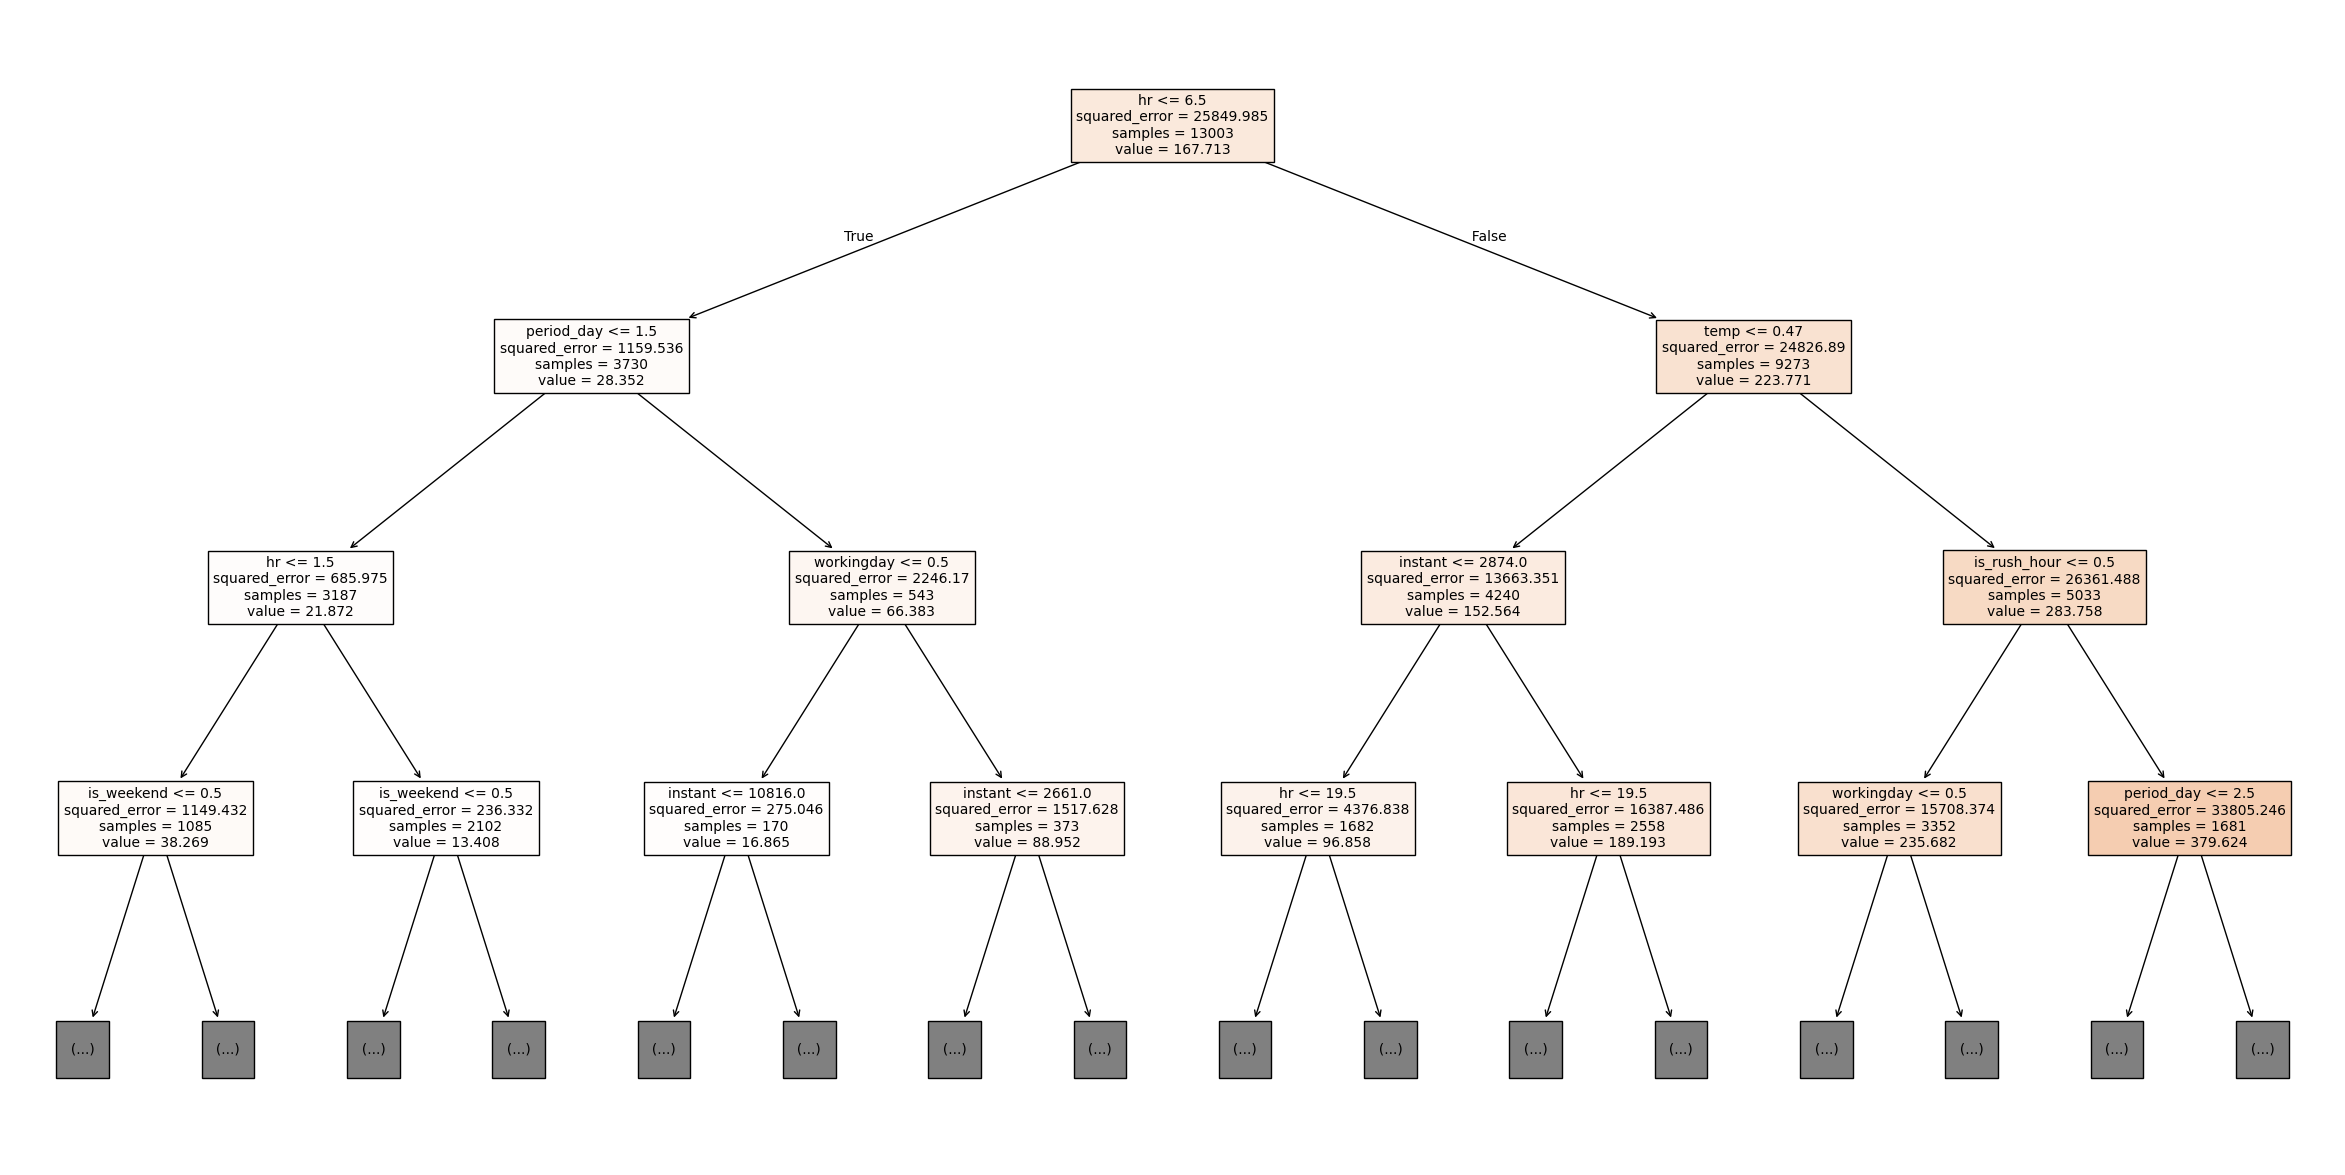

In [ ]:
plt.figure(figsize=(30, 15))

plot_tree(tree_model,
          feature_names=X_train.columns,
          filled=True,
          max_depth=3,
          fontsize=10)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                   'Importance': tree_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
4,hr,0.442321
9,temp,0.131876
0,instant,0.119326
7,workingday,0.088105
15,is_rush_hour,0.072774
13,period_day,0.046035
11,hum,0.023028
16,is_bad_weather,0.014933
14,is_weekend,0.014595
10,atemp,0.011752


Floresta Aleatória de Regressão

In [ ]:
rf_model = RandomForestRegressor(random_state=42,
                                 n_estimators=100,
                                 max_depth=10,
                                 n_jobs=-1)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
y_pred_rf

array([148.55105894, 109.99052057,  85.57719684, ..., 159.39259932,
       100.30661912,  53.08043132])

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                   'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
4,hr,0.455077
0,instant,0.116259
15,is_rush_hour,0.093207
7,workingday,0.080353
10,atemp,0.079214
9,temp,0.060458
13,period_day,0.045633
11,hum,0.020460
14,is_weekend,0.015702
8,weathersit,0.010860


XGBoost

In [ ]:
# Criando modelo XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Treinando modelo
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                   'Importance': xgb_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
4,hr,0.182130
15,is_rush_hour,0.179691
7,workingday,0.155155
9,temp,0.112119
14,is_weekend,0.091322
10,atemp,0.084032
0,instant,0.081098
8,weathersit,0.054660
11,hum,0.023635
1,season,0.014176


## Avaliação de Performance

In [ ]:
# Função para calcular métricas de regressão
def avaliar_modelo(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    return mae, rmse, r2

**MAE (Mean Absolute Error)**

O Erro Médio Absoluto (MAE) representa a média das diferenças absolutas entre os valores reais e os valores previstos.

Por exemplo, um MAE igual a 18 significa que, em média, o modelo erra aproximadamente 18 bicicletas por previsão.



**RMSE (Root Mean Squared Error)**

O Erro Quadrático Médio da Raiz (RMSE) corresponde à raiz quadrada do MSE.

Assim como o MSE, o RMSE continua penalizando erros maiores com mais intensidade, porém seu resultado pode ser interpretado diretamente na escala da variável prevista.

No contexto deste projeto, **um RMSE igual a 25 indica que o erro típico das previsões é de aproximadamente 25 bicicletas.**

**R² (Coeficiente de Determinação)**

O R² mede quanto da variabilidade dos dados é explicada pelo modelo.

Seu valor varia normalmente entre 0 e 1, sendo que valores mais próximos de 1 indicam que o modelo consegue explicar uma parcela maior da variação observada na variável alvo.


In [ ]:
mae, rmse, r2 = avaliar_modelo(y_test, y_pred_tree)

resultados_tree = pd.DataFrame({
    "Base": ["Árvore de Regressão"],
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2
})

resultados_tree

,Base,MAE,RMSE,R²
0,Árvore de Regressão,60.440356,97.957585,0.801186


In [ ]:
# Avaliando modelo
mae, rmse, r2 = avaliar_modelo(y_test, y_pred_rf)

# Organizando resultados
resultados_rf = pd.DataFrame({
    "Base": ["Random Forest"],
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2
})

resultados_rf

,Base,MAE,RMSE,R²
0,Random Forest,49.588946,76.876461,0.87755


In [ ]:
# Avaliando modelo
mae, rmse, r2 = avaliar_modelo(y_test, y_pred_xgb)

# Organizando resultados
resultados_xgb = pd.DataFrame({
    "Base": ["XGBoost"],
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2
})

resultados_xgb

,Base,MAE,RMSE,R²
0,XGBoost,47.56324,73.79779,0.887161


In [ ]:
pd.concat([
    resultados_tree,
    resultados_rf,
    resultados_xgb
])

,Base,MAE,RMSE,R²
0,Árvore de Regressão,60.440356,97.957585,0.801186
0,Random Forest,49.588946,76.876461,0.877550
0,XGBoost,47.563240,73.797790,0.887161


### Análise de Resíduos

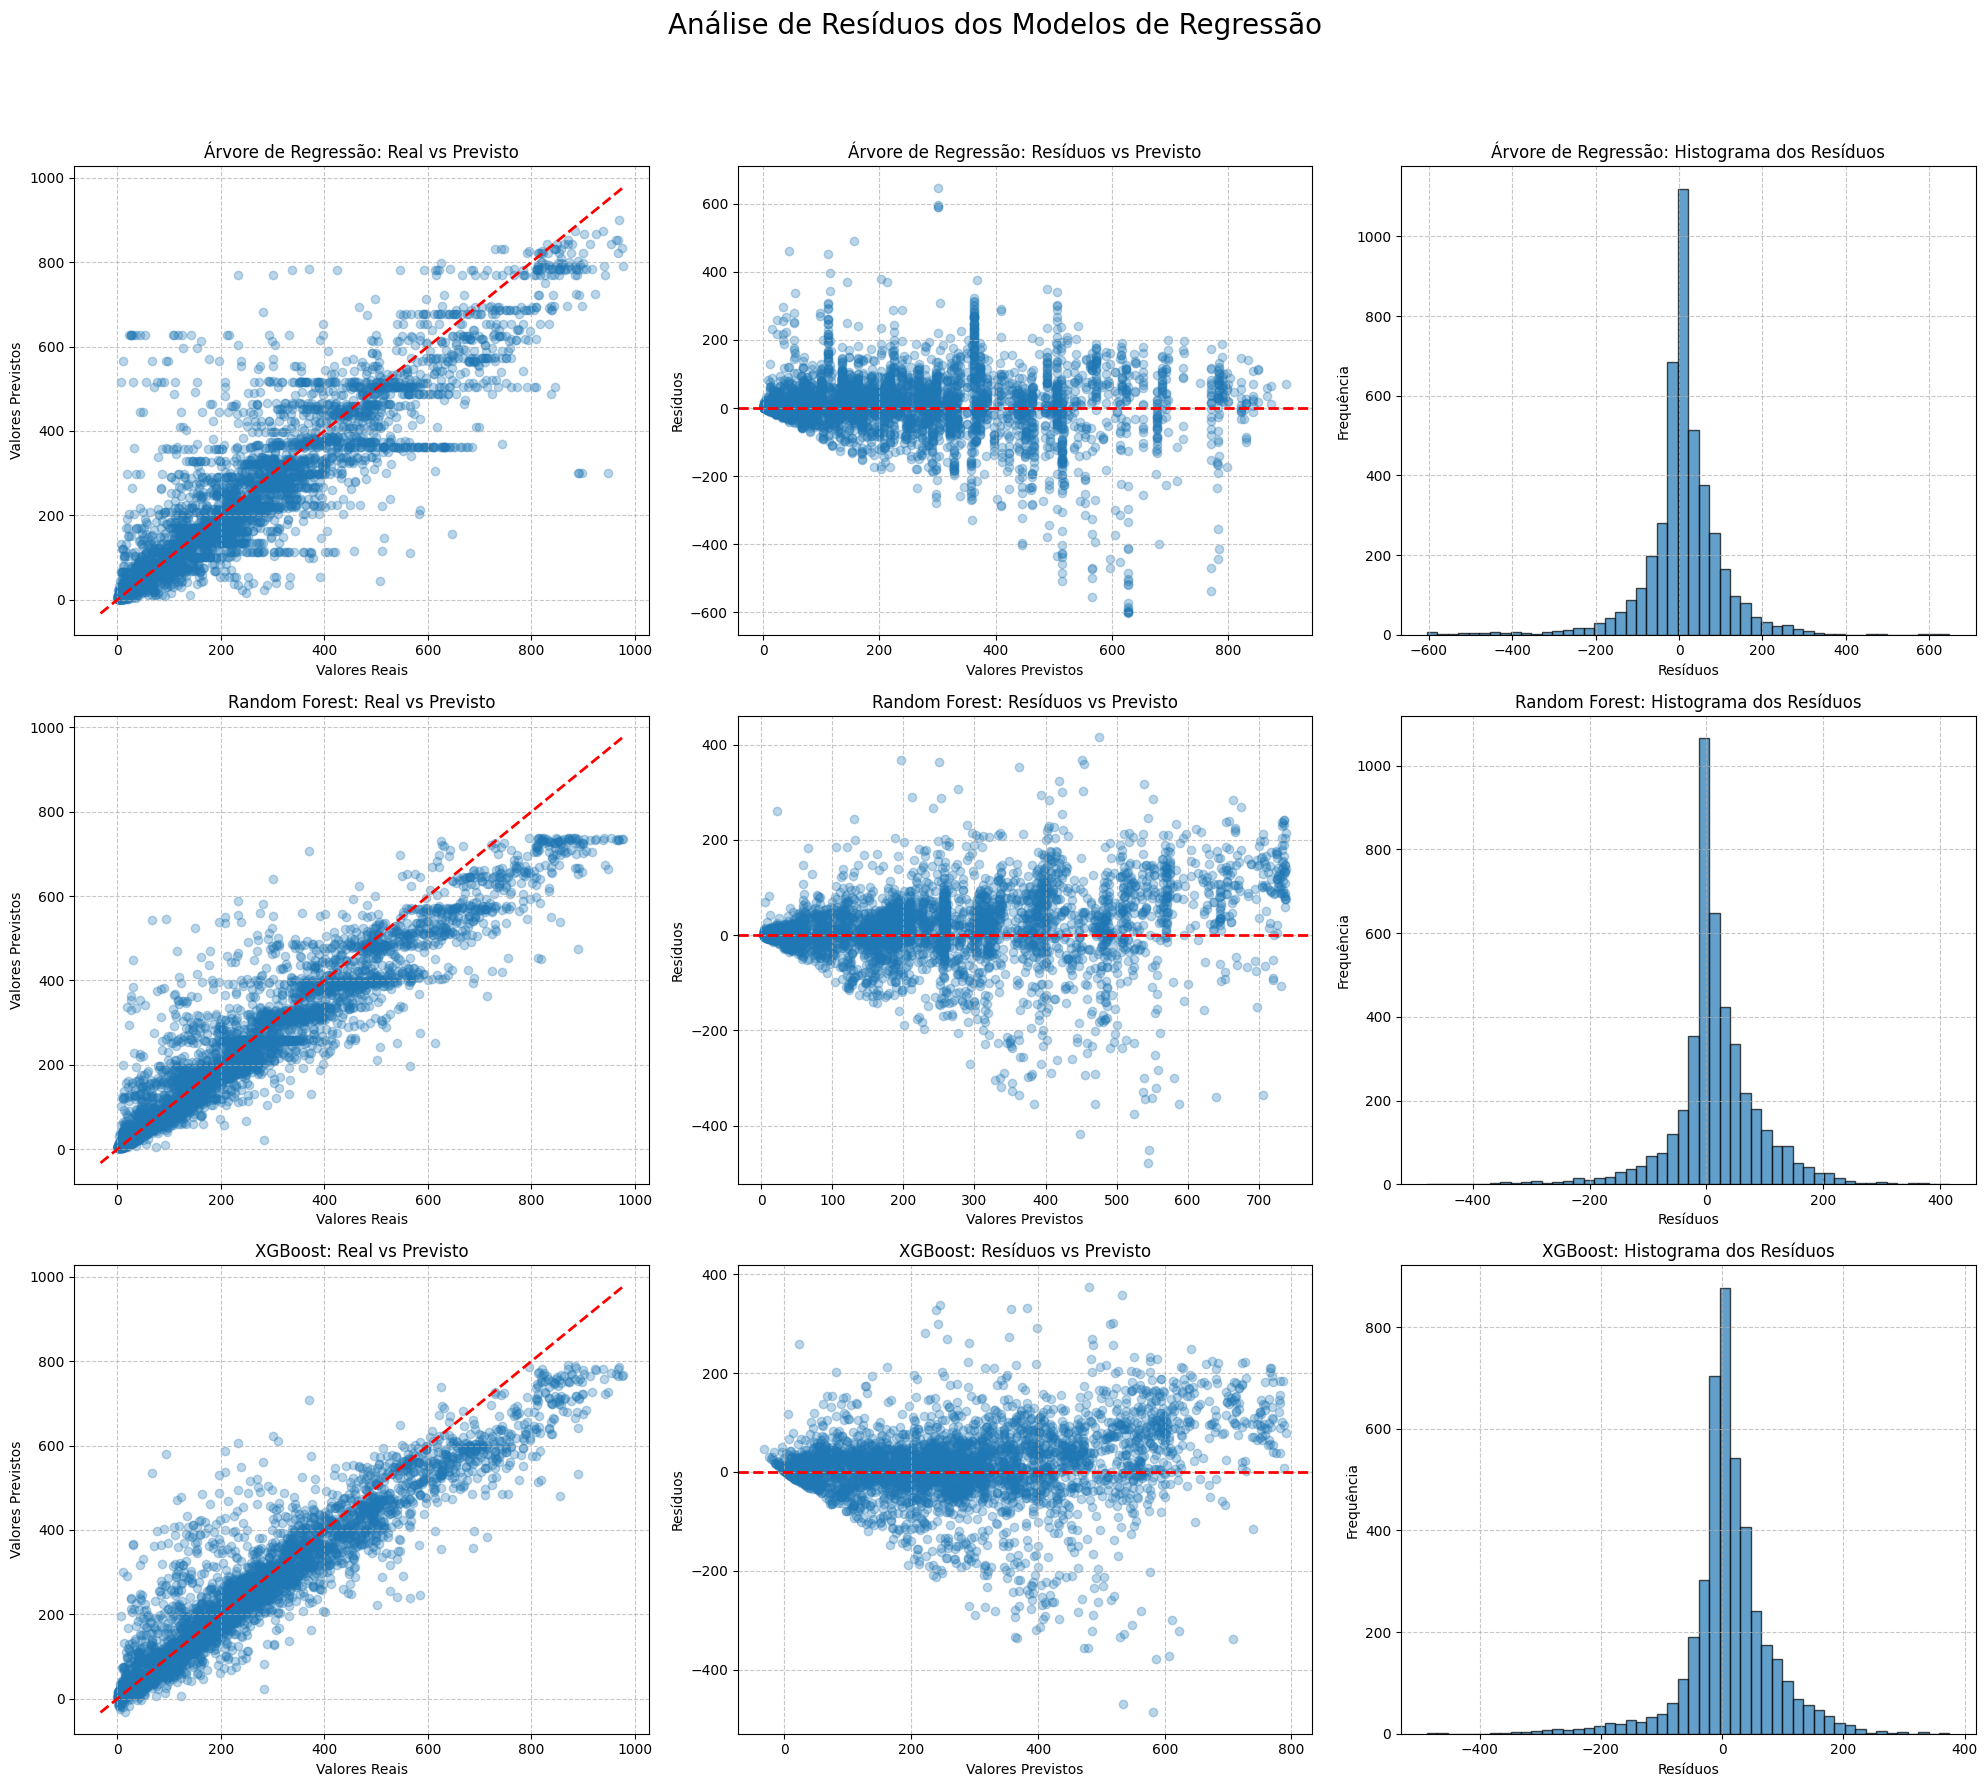

In [ ]:
# Organizar modelos e previsões
models = {
    'Árvore de Regressão': y_pred_tree,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

# Criar figura
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
fig.suptitle('Análise de Resíduos dos Modelos de Regressão', fontsize=20, y=1.02)

# Limites para linha ideal
min_value = min(y_test.min(), y_pred_tree.min(), y_pred_rf.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_tree.max(), y_pred_rf.max(), y_pred_xgb.max())

# Gerar gráficos
for row, (model_name, y_pred) in enumerate(models.items()):
    residuals = y_test - y_pred

    # Real vs Previsto
    axes[row, 0].scatter(y_test, y_pred, alpha=0.3)
    axes[row, 0].plot([min_value, max_value], [min_value, max_value], 'r--', lw=2)
    axes[row, 0].set_title(f'{model_name}: Real vs Previsto')
    axes[row, 0].set_xlabel('Valores Reais')
    axes[row, 0].set_ylabel('Valores Previstos')
    axes[row, 0].grid(True, linestyle='--', alpha=0.7)

    # Resíduos vs Previsto
    axes[row, 1].scatter(y_pred, residuals, alpha=0.3)
    axes[row, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[row, 1].set_title(f'{model_name}: Resíduos vs Previsto')
    axes[row, 1].set_xlabel('Valores Previstos')
    axes[row, 1].set_ylabel('Resíduos')
    axes[row, 1].grid(True, linestyle='--', alpha=0.7)

    # Histograma dos resíduos
    axes[row, 2].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
    axes[row, 2].set_title(f'{model_name}: Histograma dos Resíduos')
    axes[row, 2].set_xlabel('Resíduos')
    axes[row, 2].set_ylabel('Frequência')
    axes[row, 2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Análise Comparativa dos Resíduos dos Modelos

Aqui está a interpretação dos resultados observados nos gráficos de resíduos para os modelos de Árvore de Regressão, Random Forest e XGBoost:

### 1. Gráfico de Valores Reais vs. Valores Previstos (Coluna da Esquerda):

*   **Árvore de Regressão:** Os pontos estão mais dispersos em relação à linha diagonal de previsão perfeita. Há uma tendência de os pontos formarem "degraus" ou agrupamentos discretos, o que é característico de modelos baseados em árvores simples que não suavizam as previsões.
    *   **Vantagem:** Simplicidade na interpretação de como as decisões são tomadas.
    *   **Limitação:** Tendência a overfitar e menor capacidade de generalização para dados não vistos, resultando em previsões menos suaves e mais dispersas.

*   **Random Forest:** Os pontos estão visivelmente mais próximos da linha diagonal de previsão perfeita em comparação com a Árvore de Regressão. A dispersão é menor, e os agrupamentos de pontos são mais contínuos e menos acentuados.
    *   **Vantagem:** Melhor generalização e suavização das previsões devido à combinação de múltiplas árvores, reduzindo o overfitting de árvores individuais.
    *   **Limitação:** Embora melhor que a Árvore de Regressão, ainda pode haver alguma dispersão perceptível em valores de demanda mais altos, sugerindo que o modelo tem um pouco mais de dificuldade em prever os extremos com precisão.

*   **XGBoost:** Apresenta o comportamento mais próximo da linha diagonal. Os pontos estão mais concentrados e menos dispersos, indicando uma maior precisão nas previsões em todo o range de valores.
    *   **Vantagem:** Excelente capacidade de capturar relações complexas nos dados e fazer previsões precisas devido à abordagem de boosting, que constrói o modelo de forma iterativa, corrigindo os erros das previsões anteriores.
    *   **Limitação:** Pode ser mais complexo de interpretar devido à sua natureza de ensemble, e a otimização pode exigir mais recursos computacionais.

### 2. Gráfico de Resíduos vs. Valores Previstos (Coluna do Meio):

*   **Árvore de Regressão:** Observa-se uma dispersão considerável dos resíduos. Há uma ausência clara de padrões sistemáticos em algumas regiões, mas em outras, a dispersão pode parecer um pouco mais estruturada, com variações significativas ao redor do zero. A dispersão não é homogênea, indicando possível heterocedasticidade em algumas faixas de valores previstos. Os resíduos não parecem estar completamente distribuídos aleatoriamente em torno de zero, especialmente nos extremos.

*   **Random Forest:** Os resíduos demonstram uma dispersão menor em relação à linha zero em comparação com a Árvore de Regressão. A distribuição é mais centrada em zero, e a ausência de padrões sistemáticos é mais evidente. Contudo, ainda é possível observar uma ligeira tendência de aumento da variância dos resíduos para valores previstos maiores (heterocedasticidade), embora menos pronunciada que na Árvore de Regressão.

*   **XGBoost:** Este modelo exibe a menor dispersão de resíduos em torno de zero. Os pontos estão mais densamente concentrados próximos à linha horizontal zero, e a distribuição dos resíduos parece ser a mais aleatória e homogênea entre os três modelos, com menor evidência de padrões sistemáticos ou heterocedasticidade. Os resíduos parecem estar mais aleatoriamente distribuídos em torno de zero em todas as faixas de valores previstos.

### 3. Histograma dos Resíduos (Coluna da Direita):

*   **Árvore de Regressão:** O histograma mostra uma distribuição mais ampla e menos simétrica, com caudas mais pesadas e picos menos definidos em torno de zero. Isso sugere que há uma frequência maior de erros de maior magnitude.

*   **Random Forest:** O histograma é mais estreito e mais centrado em torno de zero em comparação com a Árvore de Regressão. A distribuição é mais próxima de uma normal, indicando que a maioria dos erros é menor em magnitude.

*   **XGBoost:** Apresenta o histograma mais estreito e mais claramente centrado em zero, com uma forma mais próxima de uma distribuição normal e caudas mais leves. Isso indica que o modelo gera os erros de menor magnitude e os distribui de forma mais consistente em torno da média zero.

### Conclusão:

Com base na análise visual dos gráficos de resíduos:

1.  O modelo **XGBoost** apresentou previsões mais próximas da diagonal ideal, indicando a maior precisão.
2.  O **XGBoost** também demonstrou a menor dispersão dos resíduos, com os pontos mais concentrados em torno da linha zero nos gráficos de resíduos vs. previstos, e o histograma mais estreito.
3.  O **XGBoost** mostrou a menor evidência de padrões sistemáticos nos resíduos e a distribuição mais aleatória e homogênea em torno de zero, o que sugere um bom ajuste do modelo.
4.  O **XGBoost** demonstra a melhor capacidade de generalização, pois seus resíduos são mais uniformemente distribuídos e com menor magnitude, indicando que o modelo não está nem underfitting (incapaz de capturar padrões) nem overfitting (memorizando ruído) de forma perceptível pelos gráficos em comparação com os outros.
    *   A Árvore de Regressão, com sua dispersão e "degraus", mostra indícios de ser mais propensa ao overfitting ou, no mínimo, menos robusta na generalização.

**Portanto, o modelo XGBoost apresentou o melhor desempenho geral com base na análise dos resíduos.** Ele consistentemente produz erros de menor magnitude, distribuídos de forma mais aleatória e centrados em zero, o que é um indicador de um modelo mais robusto e com melhor poder preditivo.

## Otimização de Hiperparâmetros

In [ ]:
# Função objetivo
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "objective": "reg:squarederror",
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    tscv = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -score.mean()


In [ ]:
# Criando o estudo
study = optuna.create_study(direction="minimize")

# Executando a otimização
study.optimize(objective, n_trials=30)


[I 2026-06-28 15:26:44,752] A new study created in memory with name: no-name-2c9a63cb-ccf8-482a-93e4-1161f17be7ee
[I 2026-06-28 15:26:47,578] Trial 0 finished with value: 77.32171249389648 and parameters: {'n_estimators': 396, 'max_depth': 5, 'learning_rate': 0.08283162249189296, 'subsample': 0.8378601254629529, 'colsample_bytree': 0.6122738846555388}. Best is trial 0 with value: 77.32171249389648.
[I 2026-06-28 15:26:53,553] Trial 1 finished with value: 79.3151954650879 and parameters: {'n_estimators': 440, 'max_depth': 9, 'learning_rate': 0.20998815282245, 'subsample': 0.6808523685412038, 'colsample_bytree': 0.6160244959391842}. Best is trial 0 with value: 77.32171249389648.
[I 2026-06-28 15:27:02,518] Trial 2 finished with value: 80.5609245300293 and parameters: {'n_estimators': 447, 'max_depth': 9, 'learning_rate': 0.26577207004792136, 'subsample': 0.6407814652645145, 'colsample_bytree': 0.8378796345243673}. Best is trial 0 with value: 77.32171249389648.
[I 2026-06-28 15:27:03,933]

In [ ]:
print("Melhor RMSE:", study.best_value)
print("\nMelhores hiperparâmetros:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Melhor RMSE: 73.39887008666992

Melhores hiperparâmetros:
n_estimators: 159
max_depth: 6
learning_rate: 0.051931487253826056
subsample: 0.7955819211719452
colsample_bytree: 0.9223436097851865


In [ ]:
# Treinando o modelo otimizado

best_xgb = XGBRegressor(
    **study.best_params,
    random_state=42,
    objective="reg:squarederror"
)

best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9223436097851865, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.051931487253826056,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=159, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
# Realizando previsões

y_pred_xgb_opt = best_xgb.predict(X_test)

In [ ]:
# Avaliando modelo
mae, rmse, r2 = avaliar_modelo(y_test, y_pred_xgb_opt)

# Organizando resultados
resultados_xgb_opt = pd.DataFrame({
    "Base": ["XGBoost Opt"],
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2
})

resultados_xgb_opt

,Base,MAE,RMSE,R²
0,XGBoost Opt,45.937885,72.423785,0.891324


In [ ]:
pd.concat([
    resultados_xgb,
    resultados_xgb_opt
])

,Base,MAE,RMSE,R²
0,XGBoost,47.563240,73.797790,0.887161
0,XGBoost Opt,45.937885,72.423785,0.891324


## 2. Exportação do modelo treinado

In [73]:
# Salva o modelo XGBoost otimizado
joblib.dump(best_xgb, 'bike_sharing_xgb_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

print("Modelo XGBoost otimizado salvo como 'bike_sharing_xgb_model.pkl'")

Modelo XGBoost otimizado salvo como 'bike_sharing_xgb_model.pkl'


## 3. Classe Preditiva `BikeSharingPredictor`

In [ ]:
class BikeSharingPredictor:
    def __init__(self):
        """
        Inicializa o preditor de demanda de bicicletas.

        Carrega o modelo treinado e as colunas de features esperadas
        de arquivos persistidos, garantindo que os dados de inferência
        tenham a mesma estrutura que os dados de treinamento.
        """
        self.model = joblib.load('artefacts/bike_sharing_xgb_model.pkl')
        self.feature_columns = joblib.load('artefacts/feature_columns.pkl')
        print("Modelo e colunas de features carregados com sucesso de 'artefacts/'.")

    def _create_features(self, df):
        """
        Aplica a mesma engenharia de atributos usada durante o treinamento.

        Cria as variáveis 'period_day', 'is_weekend', 'is_rush_hour'
        e 'is_bad_weather' a partir das colunas existentes no DataFrame.

        Args:
            df (pd.DataFrame): DataFrame com os dados brutos de entrada.

        Returns:
            pd.DataFrame: DataFrame com as novas features criadas.
        """
        # Garante que estamos trabalhando em uma cópia para evitar SettingWithCopyWarning
        df_processed = df.copy()

        # 1. period_day (Madrugada: 0-5, Manhã: 6-11, Tarde: 12-17, Noite: 18-23)
        df_processed['period_day'] = 0 # Valor padrão
        df_processed.loc[(df_processed['hr'] >= 0) & (df_processed['hr'] <= 5), 'period_day'] = 1  # Madrugada
        df_processed.loc[(df_processed['hr'] >= 6) & (df_processed['hr'] <= 11), 'period_day'] = 2 # Manhã
        df_processed.loc[(df_processed['hr'] >= 12) & (df_processed['hr'] <= 17), 'period_day'] = 3 # Tarde
        df_processed.loc[(df_processed['hr'] >= 18) & (df_processed['hr'] <= 23), 'period_day'] = 4 # Noite

        # 2. is_weekend (0 = Não é fim de semana, 1 = É fim de semana)
        df_processed['is_weekend'] = 0
        df_processed.loc[(df_processed['weekday'] == 0) | (df_processed['weekday'] == 6), 'is_weekend'] = 1

        # 3. is_rush_hour (1 = hora de pico, 0 = não hora de pico)
        # Horários de pico: 7-9h (manhã) e 17-19h (tarde/noite)
        df_processed['is_rush_hour'] = df_processed['hr'].apply(lambda hr: 1 if (hr >= 7 and hr <= 9) or (hr >= 17 and hr <= 19) else 0)

        # 4. is_bad_weather (1 = tempo ruim, 0 = tempo bom/regular)
        # Tempo ruim: weathersit >= 3 (chuva leve/neve, chuva forte/neve)
        df_processed['is_bad_weather'] = df_processed['weathersit'].apply(lambda x: 1 if x >= 3 else 0)

        return df_processed

    def _prepare_data(self, df):
        """
        Prepara os dados para a predição, garantindo a consistência das colunas.

        Remove colunas que não são features para o modelo e garante que a ordem
        das colunas seja a mesma utilizada durante o treinamento.

        Args:
            df (pd.DataFrame): DataFrame com os dados (já com features engenheiradas).

        Returns:
            pd.DataFrame: DataFrame pronto para ser usado no modelo.

        Raises:
            ValueError: Se as colunas do DataFrame não corresponderem às colunas
                        esperadas pelo modelo.
        """
        # Verificar se todas as colunas esperadas estão presentes após a engenharia de features
        missing_cols = set(self.feature_columns) - set(df.columns)
        if missing_cols:
            raise ValueError(f"Colunas de features ausentes no DataFrame de entrada após engenharia: {missing_cols}")

        # Reordenar as colunas para corresponder à ordem de treinamento
        # e selecionar apenas as colunas que o modelo espera
        df_final = df[self.feature_columns]

        return df_final

    def predict(self, new_raw_data):
        """
        Realiza a predição de demanda de bicicletas em novos dados brutos.

        Aplica a engenharia de atributos, prepara os dados e utiliza o modelo
        carregado para fazer as previsões.

        Args:
            new_raw_data (pd.DataFrame): Novos dados de entrada brutos para predição.
                                         Deve conter as colunas necessárias para
                                         a engenharia de atributos ('hr', 'weekday', 'weathersit')
                                         e as demais features esperadas pelo modelo.

        Returns:
            np.ndarray: Array contendo as previsões de demanda.
        """
        # 1. Engenharia de atributos
        print("Aplicando engenharia de atributos...")
        data_with_features = self._create_features(new_raw_data.copy())

        # 2. Preparação dos dados
        print("Preparando dados para o modelo...")
        prepared_data = self._prepare_data(data_with_features)

        # 3. Predição
        print("Realizando predições...")
        predictions = self.model.predict(prepared_data)

        return predictions

## 4. Exemplo de uso da classe `BikeSharingPredictor`

In [ ]:
cols_to_drop_for_raw_input = ['dteday', 'casual', 'registered', 'cnt',
                              'period_day', 'is_weekend', 'is_rush_hour', 'is_bad_weather']

# Criando um sample que simula novos dados brutos para predição.
# Pegamos as primeiras 5 linhas do DataFrame 'teste' e removemos as colunas
# que seriam geradas ou não seriam parte da entrada bruta para predição.
new_raw_data_sample = teste.drop(columns=cols_to_drop_for_raw_input, errors='ignore').head(5)

# Instanciar a classe preditiva. A classe agora carrega o modelo e as colunas internamente.
predictor = BikeSharingPredictor()

# Realizar previsões em novos dados
sample_predictions = predictor.predict(new_raw_data_sample)

print("\nPrevisões de demanda para os dados de exemplo:")

results_df = new_raw_data_sample.copy()
results_df['predicted_cnt'] = np.round(sample_predictions).astype(int)
results_df['actual_cnt'] = teste.head(5)['cnt'].values # Adiciona o valor real para comparação
display(results_df[['hr', 'temp', 'actual_cnt', 'predicted_cnt']])

Modelo e colunas de features carregados com sucesso de 'artefacts/'.
Aplicando engenharia de atributos...
Preparando dados para o modelo...
Realizando predições...

Previsões de demanda para os dados de exemplo:


,hr,temp,actual_cnt,predicted_cnt
13003,0,0.76,149,135
13004,1,0.74,93,98
13005,2,0.72,90,76
13006,3,0.72,33,45
13007,4,0.70,4,30
